<a href="https://colab.research.google.com/github/Jabir4TZ/Jabir4TZ/blob/main/Jabir_Ayindo_ML_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Used Car Price Prediction - Capstone Project


1. Goal: Predict the selling price of used cars based on features like make, model,mileage, etc.
-  We will use a regression-based Machine Learning approach.

# 1. Data Gathering and importing relevant Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the 'used_cars' dataset

In [ ]:
df =pd.read_csv('used_cars.csv')
df.head()

# 3. Decide which ML technique to use
-Since this is a structured dataset with a tabular format, I will use classical Machine Learning techniques (Regression models).

# 4. Exploratory Data Analysis (EDA)
* I will undertake the below approach into EDA process:

  
a. Data Preprocessing
A.1. Check the structure and types
A.2. View basic statistics
A.3. Display first few rows

b. Data Visualization
B.1. Plot distribution of the selling price

c. Handling Missing Values
C.1. Check for missing values per column
C.2. Note: Dataset is already clean (0 missing values)

d. Handling Outliers
D.1. Visualize numeric columns using boxplots

e. Handling Skewness
E.1. Apply log transformation to highly skewed columns
E.2. Show histogram of log-transformed km_driven
E.3. Optional: Apply transformation to the original column

f. Data Encoding
F.1. Convert categorical variables using one-hot encoding

g. Feature Engineering
G.1. No additional features engineered in this version

h. Feature Scaling
H.1. Will be done after splitting data

i. Feature Selection
I.1. Drop irrelevant or redundant features

In [ ]:
### a. Data Preprocessing A.1. Check the structure and types, View basic statistics,Display first few rows

In [ ]:
df.info()
df.describe()
df.head()
df.tail

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2119 entries, 0 to 2118
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   car_name       2119 non-null   object 
 1   brand          2119 non-null   object 
 2   model          2119 non-null   object 
 3   vehicle_age    2119 non-null   int64  
 4   km_driven      2119 non-null   int64  
 5   mileage        2119 non-null   float64
 6   max_power      2119 non-null   float64
 7   seats          2119 non-null   int64  
 8   selling_price  2119 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 149.1+ KB


<bound method NDFrame.tail of             car_name    brand    model  vehicle_age  km_driven  mileage  \
0        Maruti Alto   Maruti     Alto            9     120000    19.70   
1        Maruti Alto   Maruti     Alto            9      37000    20.92   
2     Maruti Wagon R   Maruti  Wagon R            8      35000    18.90   
3     Maruti Wagon R   Maruti  Wagon R            3      17512    20.51   
4      Hyundai Venue  Hyundai    Venue            2      20000    18.15   
...              ...      ...      ...          ...        ...      ...   
2114  Maruti Celerio   Maruti  Celerio            6      60000    23.10   
2115     Maruti Alto   Maruti     Alto            7      44000    30.46   
2116    Renault KWID  Renault     KWID            4      29847    24.04   
2117     Maruti Alto   Maruti     Alto            4      12706    24.70   
2118    Renault KWID  Renault     KWID            2       2700    25.17   

      max_power  seats  selling_price  
0         46.30      5       

### b. Data Visualization - Histogram

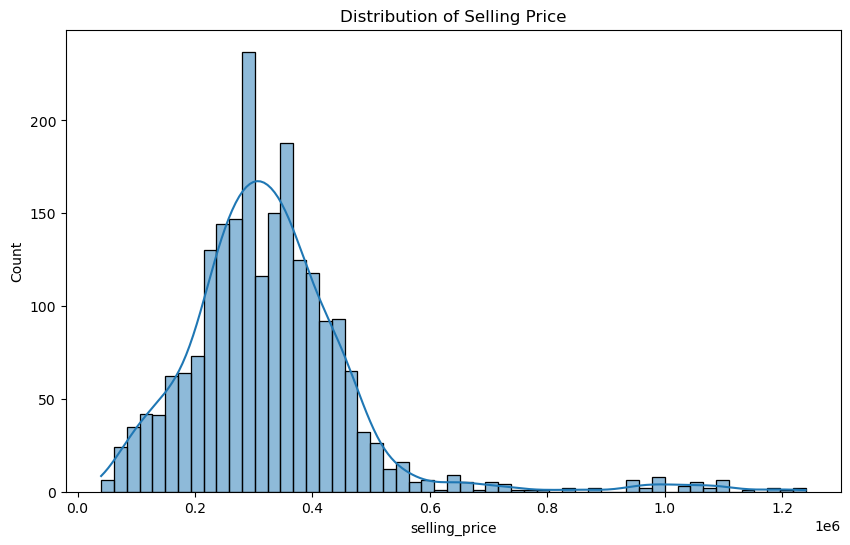

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], kde=True)
plt.title('Distribution of Selling Price')
plt.show()


### c. Handling Missing Values

In [ ]:
print("Missing values per column:\n", df.isnull().sum()) # To check if the Dataset is clean and has no missing values

Missing values per column:
 car_name         0
brand            0
model            0
vehicle_age      0
km_driven        0
mileage          0
max_power        0
seats            0
selling_price    0
dtype: int64


#### d. Handling Outliers (visualizing numeric columns)

<Axes: >

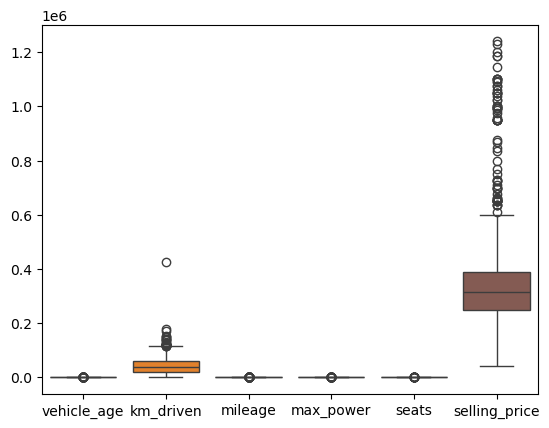

In [ ]:
sns.boxplot(df)

### e. Handling Skewness
- - I'll apply log transformation to highly skewed columns

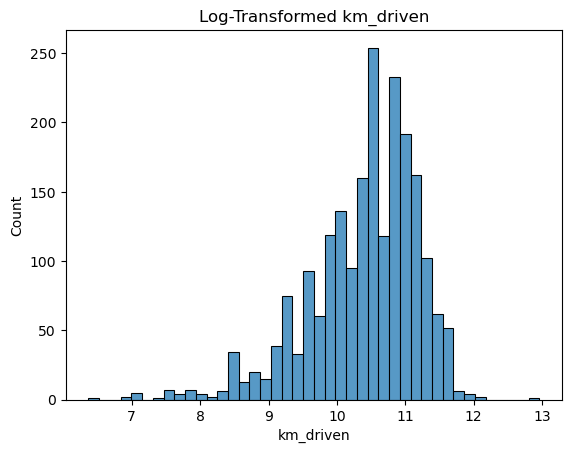

In [ ]:
# We'll apply log transformation to highly skewed columns
sns.histplot(np.log1p(df['km_driven']))
plt.title("Log-Transformed km_driven")
plt.show()

### f. Data Encoding
- Convert categorical variables using one-hot encoding

In [ ]:
df_encoded = pd.get_dummies(df, columns=['brand', 'model'], drop_first=True)

In [ ]:
# g. Feature Engineering - No additional features engineered in this version

In [ ]:
# h. Feature Scaling - will be done after splitting data

### i. Feature Selection - dropping irrelevant or redundant features
- 5. Separate Features and Target Variable (X, y)

In [ ]:
X = df_encoded.drop(['car_name', 'selling_price'], axis=1)
y = df_encoded['selling_price']

# 6. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Baseline Model 1: Linear Regression

- Import the model
- Initialize
- Train the model


In [ ]:
lr_model = LinearRegression()

### c. Train the model

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

### d. Make predictions

In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)

# 8. Evaluation of Model 1

In [ ]:
print("Linear Regression Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Evaluation:
MAE: 463742655960261.4
MSE: 9.11842743915019e+31
RMSE: 9549045731982956.0
R2 Score: -5.014684882727205e+21


# 9. Hyperparameter Tuning - will apply on Random Forest model

# 10. Re-evaluate the model - Not applicable to Linear Regression here

# 11. Baseline Model 2: Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 12. Evaluate Model 2

In [ ]:
print("\nRandom Forest Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest Evaluation:
MAE: 36038.45059814399
MSE: 2086861865.9890022
RMSE: 45682.18324455391
R2 Score: 0.8852329009409736


### Hyperparameter tuning using GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

### Best model

In [ ]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

In [ ]:
print("\nTuned Random Forest Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2 Score:", r2_score(y_test, y_pred_best))



Tuned Random Forest Evaluation:
MAE: 34839.30828687482
MSE: 1885580664.1201286
RMSE: 43423.2733003873
R2 Score: 0.8963023732477367


13. Deployment - (next steps)
- In practice, save the model using joblib or pickle
- import joblib
- joblib.dump(best_rf, 'car_price_model.pkl')

In [ ]:
import joblib

In [ ]:
joblib.dump(best_rf, 'car_price_model.pkl')

['car_price_model.pkl']